In [89]:
import pandas as pd        

# confirm the working directory and file existence
import os
print("cwd:", os.getcwd())
print("exists:", os.path.isfile("personal_finance_dataset.xlsx"))

# read the 'datathon_finance' sheet from the Excel file
df = pd.read_excel("personal_finance_dataset.xlsx", sheet_name="datathon_finance")

column_mapping = {
    'PAGEMIEG': 'Age_Group',
    'PATTCRU':  'Credit_Card_Payment_Behavior',
    'PATTSITC': 'COVID_Financial_Impact',
    'PATTSKP':  'Skipped_Payments',
    'PEDUCMIE': 'Education_Level',
    'PEFATINC': 'Annual_After_Tax_Income',
    'PFMTYPG':  'Family_Type',
    'PFTENUR':  'Home_Ownership',
    'PLFFPTME': 'Work_Status_2022',
    'PNBEARG':  'Number_of_Earners',
    'PPVRES':   'Province',
    'PWAPRVAL': 'Home_Value',
    'PWASTDEP': 'Bank_Deposits',
    'PWATFS':   'TFSA_Balance',
    'PWDPRMOR': 'Mortgage_Debt',
    'PWDSLOAN': 'Student_Loan_Debt',
    'PWDSTCRD': 'Credit_Card_Debt',
    'PWDSTLOC': 'Line_of_Credit_Debt',
    'PWNETWPG': 'Net_Worth'
}

df.rename(columns=column_mapping, inplace=True)

print(df.head())

cwd: /Users/haianhha/Documents/GitHub/JTAFinance
exists: True
   Age_Group  Credit_Card_Payment_Behavior  COVID_Financial_Impact  \
0          6                             4                       3   
1          7                             4                       3   
2          5                             4                       3   
3          6                             3                       3   
4          4                             4                       3   

   Skipped_Payments  Education_Level  Annual_After_Tax_Income  Family_Type  \
0                 2                4                   115525            4   
1                 2                9                   121300            2   
2                 2                4                    19175            2   
3                 2                4                   147425            2   
4                 2                3                    56750            1   

   Home_Ownership  Work_Status_2022  Number_of_E

In [90]:
import numpy as np

def define_resilience(df, shock_percentage=0.15):
    
    # 1. ANNUAL EXPENSE & LIQUIDITY
    df['Total_Liquidity'] = df['Bank_Deposits'] + df['TFSA_Balance']

    df['Annual_Expenses_Base'] = (df['Annual_After_Tax_Income'] * 0.6)  # Annual Expense Proxy (60% of income)
    
    df['Years_of_Runway'] = df['Total_Liquidity'] / df['Annual_Expenses_Base'].replace(0, np.nan)  # Calculate Runway in years (How many years they can cover expenses with liquid assets if income drops to zero)
    

    # 2. HOUSING BURDEN
    # Owners (Home_Ownership == 2): Proxy 4% of Mortgage Debt as annual cost
    # Renters (Home_Ownership == 3): Proxy 30% of income as annual rent
    df['Est_Annual_Housing_Cost'] = np.where(
        df['Home_Ownership'] == 2, 
        df['Mortgage_Debt'] * 0.04, 
        np.where(df['Home_Ownership'] == 3, df['Annual_After_Tax_Income'] * 0.30, 0))
    
    df['Housing_Burden_Ratio'] = df['Est_Annual_Housing_Cost'] / df['Annual_After_Tax_Income'].replace(0, np.nan)  # Housing Burden Ratio (Costs / Income)


    # 3. CONSUMER DEBT BURDEN
    # Calculate Total Non-Mortgage Debt 
    df['Total_Consumer_Debt'] = df['Credit_Card_Debt'] + df['Line_of_Credit_Debt'] + df['Student_Loan_Debt']

    # Annual Debt-to-Income Ratio
    # A ratio > 0.5 is often considered "serious financial strain" in Canadian banking
    df['DTI_Ratio'] = df['Total_Consumer_Debt'] / df['Annual_After_Tax_Income'].replace(0, np.nan)


    # 4. THE "AT-RISK" TARGET VARIABLE
    # "At Risk" Baseline (No shock):
    #         - Less than 3 months (0.25 yrs) runway
    #         - High Housing Burden (>30%)
    #         - High DTI Ratio (>50%) 
    #         - Skipped Payments
    df['Is_At_Risk_Base'] = np.where(
        (df['Years_of_Runway'] < 0.25) | 
        (df['Housing_Burden_Ratio'] > 0.3) | 
        (df['DTI_Ratio'] > 0.50) |             
        (df['Skipped_Payments'] == 1), 1, 0)
   
    return df

df = define_resilience(df, shock_percentage=0.15)


In [91]:
# Define a function to apply economic shocks and determine new vulnerability status
# For each shock type, we will recalculate the relevant financial metrics but Skipped_Payments is not recalculated because it’s a past behavior, not a formula.
def apply_economic_shock(df, shock_type="expenses", severity=0.15):
    temp_df = df.copy()

    runway = temp_df['Years_of_Runway']
    burden = temp_df['Housing_Burden_Ratio']
    dti = temp_df['DTI_Ratio']

    if shock_type == "expenses":
        # Scenario 1: Inflation Shock (Increase Expenses)
        # recalculate runway with increased expenses
        shocked_expenses = temp_df['Annual_Expenses_Base'] * (1 + severity)
        runway = temp_df['Total_Liquidity'] / shocked_expenses.replace(0, np.nan)
        
    elif shock_type == "mortgage":
        # Scenario 2: Housing Shock (Increase Mortgage Costs)
        # Recalculates housing burden
        housing_cost = np.where(
        temp_df['Home_Ownership'] == 2,
        temp_df['Mortgage_Debt'] * (0.04 * (1 + severity)),  # increase interest rate
        np.where(
            temp_df['Home_Ownership'] == 3,
            temp_df['Annual_After_Tax_Income'] * 0.30, 0))       # renters unchanged
        burden = housing_cost / temp_df['Annual_After_Tax_Income'].replace(0, np.nan)
        
    elif shock_type == "rent":
        # Scenario 3: Housing Shock (Increase Rent Costs for Renters only)
        # Recalculates housing burden
        housing_cost = np.where(
            temp_df['Home_Ownership'] == 2,
            temp_df['Mortgage_Debt'] * 0.04,
            np.where(
                temp_df['Home_Ownership'] == 3,
                temp_df['Annual_After_Tax_Income'] * 0.30 * (1 + severity), 0)) # Owners unchanged, Renters increase
        burden = housing_cost / temp_df['Annual_After_Tax_Income'].replace(0, np.nan)

    elif shock_type == "income":
        # Scenario 4: Recession Shock (Decrease Income)
        # Re-calc housing burden, DTI, and runway with decreased income
        shocked_income = temp_df['Annual_After_Tax_Income'] * (1 - severity)
        shocked_expenses = shocked_income * 0.6   # Assuming expenses change proportionally to income
        runway = temp_df['Total_Liquidity'] / shocked_expenses.replace(0, np.nan)
        burden = temp_df['Est_Annual_Housing_Cost'] / shocked_income.replace(0, np.nan)
        dti = temp_df['Total_Consumer_Debt'] / shocked_income.replace(0, np.nan)
    
    else:
        raise ValueError("shock_type must be one of: 'expenses', 'mortgage', 'income', 'rent'")
    
    is_at_risk = (
        (runway < 0.25) |
        (burden > 0.3) |
        (dti > 0.50) |
        (temp_df['Skipped_Payments'] == 1)
    ).astype(int)

    # Return the "Flipped" status: Safe before, At Risk now
    return ((df['Is_At_Risk_Base'] == 0) & (is_at_risk == 1)).astype(int)

df['Vulnerable_Inflation'] = apply_economic_shock(df, "expenses", 0.15)
df['Vulnerable_Mortgage'] = apply_economic_shock(df, "mortgage", 0.15)
df['Vulnerable_Rent']      = apply_economic_shock(df, "rent", 0.15)
df['Vulnerable_Income']    = apply_economic_shock(df, "income", 0.15)

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Summary Table by Age Group
age_labels = {1: '18-24', 2: '25-34', 3: '35-44', 4: '45-54'}
df['Vulnerable_Rent']      = apply_economic_shock(df, "rent", 0.15)
summary_table = df.groupby('Age_Group')[['Is_At_Risk_Base', 'Vulnerable_Inflation', 'Vulnerable_Mortgage', 'Vulnerable_Income', 'Vulnerable_Rent']].mean() * 100
summary_table.index = summary_table.index.map(age_labels)

print("Financial Fragility by Age Group (%):")
print(summary_table)


Financial Fragility by Age Group (%):
           Is_At_Risk_Base  Vulnerable_Inflation  Vulnerable_Mortgage  \
Age_Group                                                               
18-24            64.500000              1.500000             0.500000   
25-34            55.299861              2.231520             0.278940   
35-44            57.863903              2.163137             0.495719   
45-54            56.330128              2.203526             0.280449   
NaN              43.338816              1.507675             0.082237   
NaN              31.022704              1.848503             0.120555   
NaN              22.020521              0.947119             0.000000   

           Vulnerable_Income  Vulnerable_Rent  
Age_Group                                      
18-24              24.000000        23.000000  
25-34              19.037657        18.270572  
35-44              10.905813        10.184768  
45-54               7.411859         6.530449  
NaN             

/var/folders/12/9c7n0p_101z2n53fw4xvcqfw0000gn/T/ipykernel_94032/675033586.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


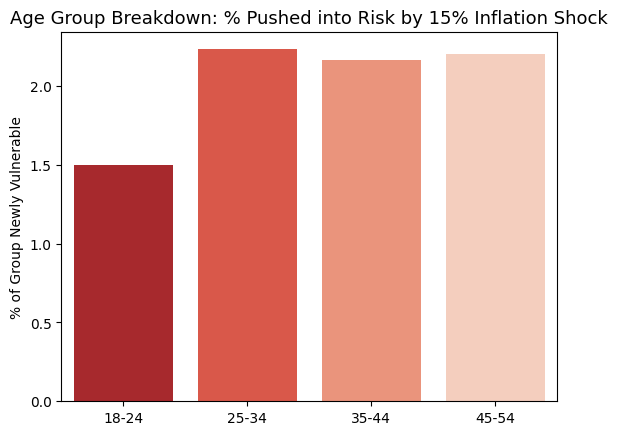

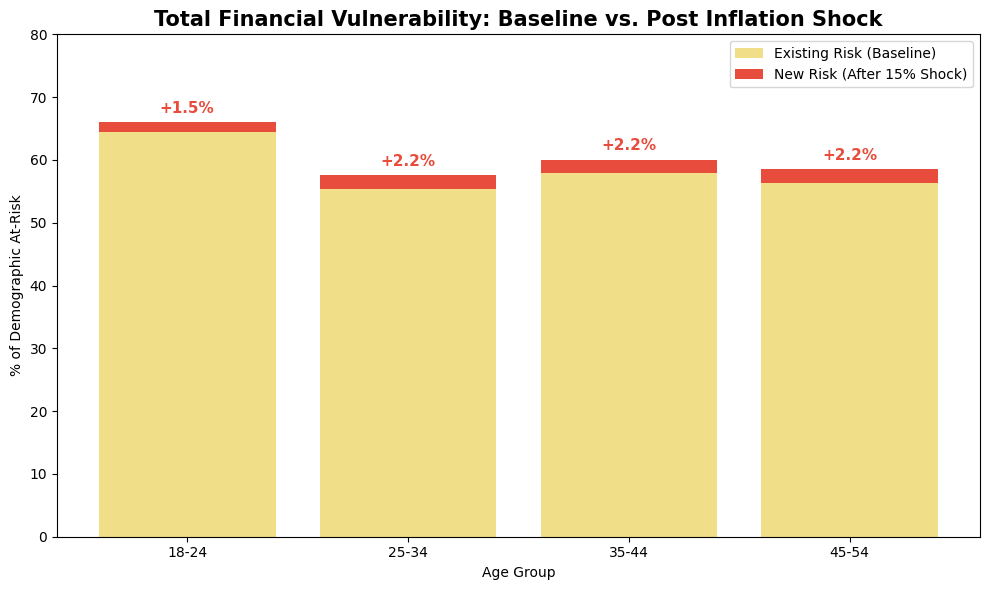

In [93]:
# SHOCK SCENARIO 1: 15% Increase in Expenses (Inflation Shock)
df['Vulnerable_Inflation'] = apply_economic_shock(df, "expenses", 0.15)
shock_summary = df.groupby('Age_Group')[['Is_At_Risk_Base', 'Vulnerable_Inflation']].mean() * 100
plot_data = shock_summary.loc[[1, 2, 3, 4]]

# Chart 1: Bar chart of % newly vulnerable by age group after inflation shock
# Visualize the % of each age group that became vulnerable after the shock
sns.barplot(
    x=['18-24', '25-34', '35-44', '45-54'], 
    y=plot_data['Vulnerable_Inflation'], 
    palette='Reds_r'
)
plt.title('Age Group Breakdown: % Pushed into Risk by 15% Inflation Shock', fontsize=13)
plt.ylabel('% of Group Newly Vulnerable')
plt.show()

# Chart 2: Stacked Bar Chart of Baseline Risk vs. New Risk After Inflation Shock
# Create a stacked bar chart comparing baseline risk vs. new risk after shock for each age group, to answer: "How much did the shock increase vulnerability in each age group?" 
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(plot_data.index, plot_data['Is_At_Risk_Base'], 
       label='Existing Risk (Baseline)', color="#eed66b", alpha=0.8)

ax.bar(plot_data.index, plot_data['Vulnerable_Inflation'], 
       bottom=plot_data['Is_At_Risk_Base'], 
       label='New Risk (After 15% Shock)', color='#e74c3c')

ax.set_xticks([1, 2, 3, 4]) # Set the position of the ticks
ax.set_xticklabels(['18-24', '25-34', '35-44', '45-54']) # Set the text labels

plt.title('Total Financial Vulnerability: Baseline vs. Post Inflation Shock', fontsize=15, fontweight='bold')
plt.ylabel('% of Demographic At-Risk')
plt.xlabel('Age Group')
plt.ylim(0, 80)
plt.legend()

for i, age_idx in enumerate(plot_data.index):
    base_val = plot_data.loc[age_idx, 'Is_At_Risk_Base']
    shock_val = plot_data.loc[age_idx, 'Vulnerable_Inflation']
    total = base_val + shock_val
    
    # Label for the "New Risk" spike
    plt.text(age_idx, total + 1.5, f"+{shock_val:.1f}%", 
             ha='center', color='#e74c3c', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

/var/folders/12/9c7n0p_101z2n53fw4xvcqfw0000gn/T/ipykernel_94032/1077693809.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


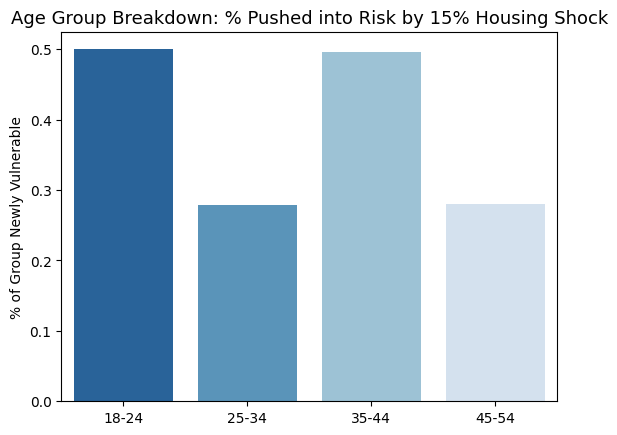

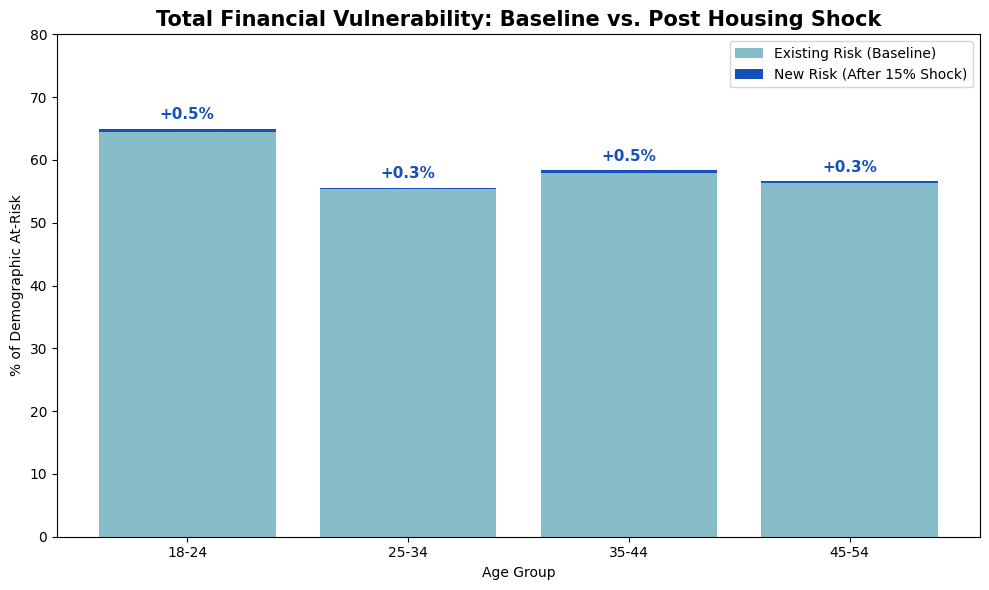

In [94]:
# SHOCK SCENARIO 2: 15% Increase in Mortgage Costs (Housing Shock)
df['Vulnerable_Housing'] = apply_economic_shock(df, "mortgage", 0.15)
shock_summary = df.groupby('Age_Group')[['Is_At_Risk_Base', 'Vulnerable_Housing']].mean() * 100
plot_data = shock_summary.loc[[1, 2, 3, 4]]

# Chart 1: Bar chart of % newly vulnerable by age group after shock
# Visualize the % of each age group that became vulnerable after the shock
sns.barplot(
    x=['18-24', '25-34', '35-44', '45-54'], 
    y=plot_data['Vulnerable_Housing'], 
    palette='Blues_r'
)
plt.title('Age Group Breakdown: % Pushed into Risk by 15% Housing Shock', fontsize=13)
plt.ylabel('% of Group Newly Vulnerable')
plt.show()

# Chart 2: Stacked Bar Chart of Baseline Risk vs. New Risk After Shock
# Create a stacked bar chart comparing baseline risk vs. new risk after shock for each age group, to answer: "How much did the shock increase vulnerability in each age group?" 
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(plot_data.index, plot_data['Is_At_Risk_Base'], 
       label='Existing Risk (Baseline)', color="#69adbb", alpha=0.8)

ax.bar(plot_data.index, plot_data['Vulnerable_Housing'], 
       bottom=plot_data['Is_At_Risk_Base'], 
       label='New Risk (After 15% Shock)', color="#1650bb")

ax.set_xticks([1, 2, 3, 4]) # Set the position of the ticks
ax.set_xticklabels(['18-24', '25-34', '35-44', '45-54']) # Set the text labels

plt.title('Total Financial Vulnerability: Baseline vs. Post Housing Shock', fontsize=15, fontweight='bold')
plt.ylabel('% of Demographic At-Risk')
plt.xlabel('Age Group')
plt.ylim(0, 80)
plt.legend()

for i, age_idx in enumerate(plot_data.index):
    base_val = plot_data.loc[age_idx, 'Is_At_Risk_Base']
    shock_val = plot_data.loc[age_idx, 'Vulnerable_Housing']
    total = base_val + shock_val
    
    # Label for the "New Risk" spike
    plt.text(age_idx, total + 1.5, f"+{shock_val:.1f}%", 
             ha='center', color='#1650bb', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

/var/folders/12/9c7n0p_101z2n53fw4xvcqfw0000gn/T/ipykernel_94032/1438518209.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


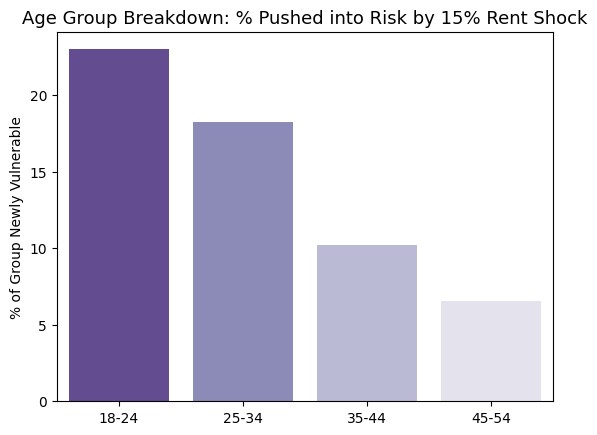

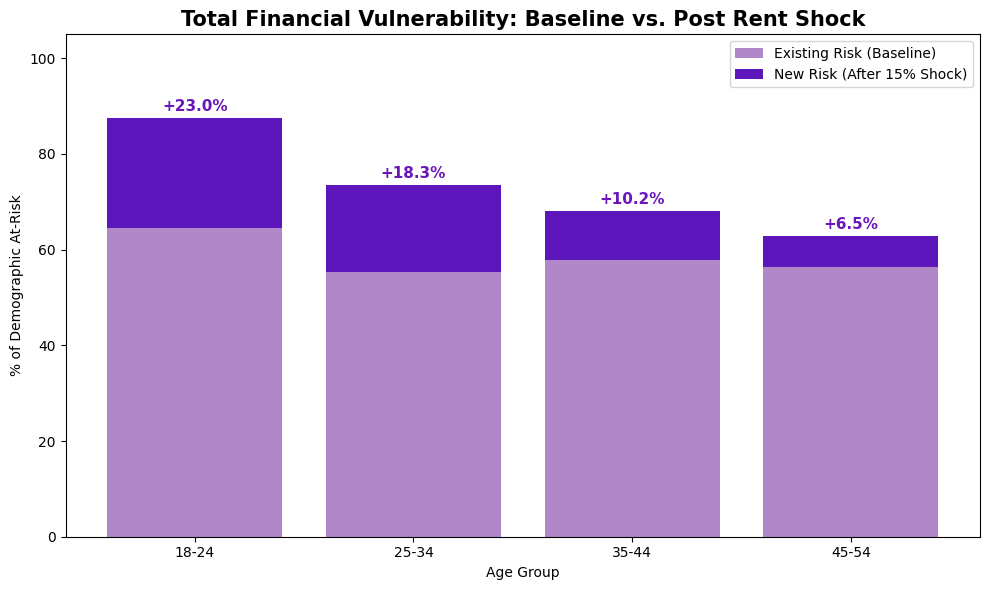

In [95]:
#  SHOCK SCENARIO 3: 15% Increase in Renting Costs (Housing Shock)
df['Vulnerable_Rent'] = apply_economic_shock(df, "rent", 0.15)
df['Vulnerable_Rent']      = apply_economic_shock(df, "rent", 0.15)
shock_summary = df.groupby('Age_Group')[['Is_At_Risk_Base', 'Vulnerable_Rent']].mean() * 100
plot_data = shock_summary.loc[[1, 2, 3, 4]]
# Chart 1: Bar chart of % newly vulnerable by age group after shock
# Visualize the % of each age group that became vulnerable after the shock
sns.barplot(
    x=['18-24', '25-34', '35-44', '45-54'], 
    y=plot_data['Vulnerable_Rent'], 
    palette='Purples_r'
)
plt.title('Age Group Breakdown: % Pushed into Risk by 15% Rent Shock', fontsize=13)
plt.ylabel('% of Group Newly Vulnerable')
plt.show()

# Chart 2: Stacked Bar Chart of Baseline Risk vs. New Risk After Shock
# Create a stacked bar chart comparing baseline risk vs. new risk after shock for each age group, to answer: "How much did the shock increase vulnerability in each age group?" 
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(plot_data.index, plot_data['Is_At_Risk_Base'], 
       label='Existing Risk (Baseline)', color="#9d69bb", alpha=0.8)

ax.bar(plot_data.index, plot_data['Vulnerable_Rent'], 
       bottom=plot_data['Is_At_Risk_Base'], 
       label='New Risk (After 15% Shock)', color="#5d16bb")

ax.set_xticks([1, 2, 3, 4]) # Set the position of the ticks
ax.set_xticklabels(['18-24', '25-34', '35-44', '45-54']) # Set the text labels

plt.title('Total Financial Vulnerability: Baseline vs. Post Rent Shock', fontsize=15, fontweight='bold')
plt.ylabel('% of Demographic At-Risk')
plt.xlabel('Age Group')
plt.ylim(0, 105)
plt.legend()

for i, age_idx in enumerate(plot_data.index):
    base_val = plot_data.loc[age_idx, 'Is_At_Risk_Base']
    shock_val = plot_data.loc[age_idx, 'Vulnerable_Rent']
    total = base_val + shock_val
    
    # Label for the "New Risk" spike
    plt.text(age_idx, total + 1.5, f"+{shock_val:.1f}%", 
             ha='center', color="#6b16bb", fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

/var/folders/12/9c7n0p_101z2n53fw4xvcqfw0000gn/T/ipykernel_94032/3906299760.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


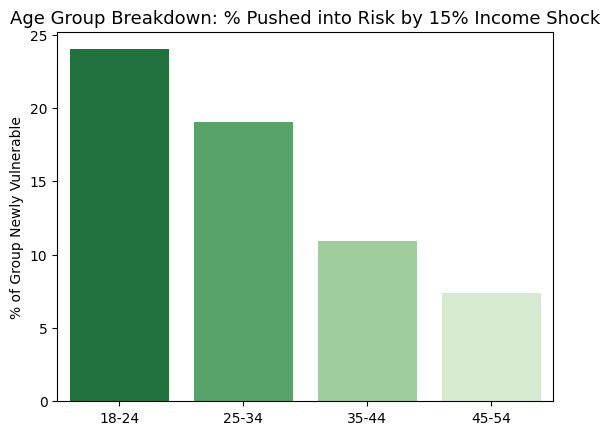

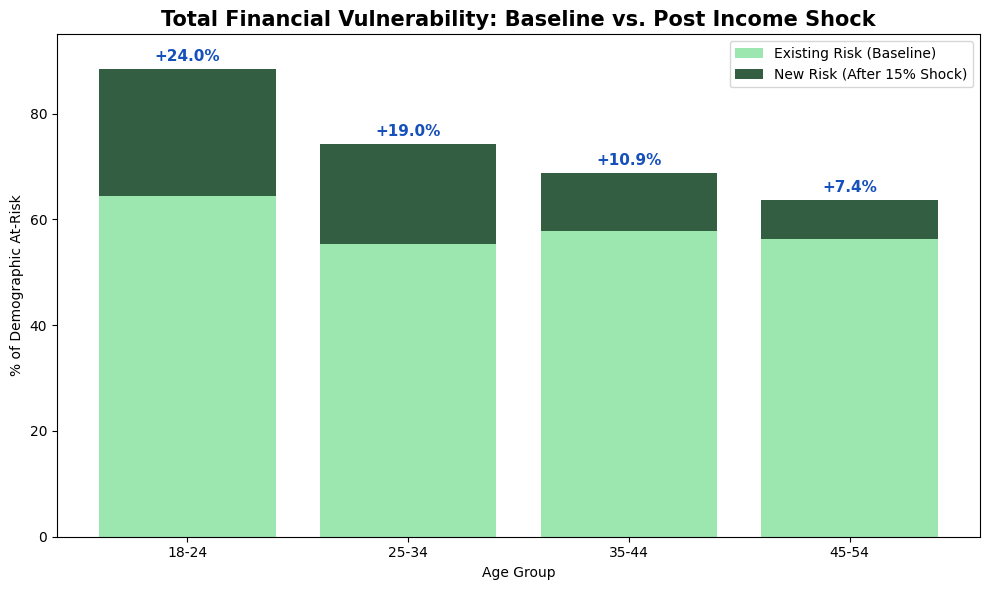

In [96]:
# SHOCK SCENARIO 4: 15% Decrease in Income (Recession/Job Loss Shock)
df['Vulnerable_Income'] = apply_economic_shock(df, "income", 0.15)
shock_summary = df.groupby('Age_Group')[['Is_At_Risk_Base', 'Vulnerable_Income']].mean() * 100
plot_data = shock_summary.loc[[1, 2, 3, 4]]

# Chart 1: Bar chart of % newly vulnerable by age group after shock
# Visualize the % of each age group that became vulnerable after the shock
sns.barplot(
    x=['18-24', '25-34', '35-44', '45-54'], 
    y=plot_data['Vulnerable_Income'], 
    palette='Greens_r'
)
plt.title('Age Group Breakdown: % Pushed into Risk by 15% Income Shock', fontsize=13)
plt.ylabel('% of Group Newly Vulnerable')
plt.show()

# Chart 2: Stacked Bar Chart of Baseline Risk vs. New Risk After Shock
# Create a stacked bar chart comparing baseline risk vs. new risk after shock for each age group, to answer: "How much did the shock increase vulnerability in each age group?" 
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(plot_data.index, plot_data['Is_At_Risk_Base'], 
       label='Existing Risk (Baseline)', color="#84E09B", alpha=0.8)

ax.bar(plot_data.index, plot_data['Vulnerable_Income'], 
       bottom=plot_data['Is_At_Risk_Base'], 
       label='New Risk (After 15% Shock)', color="#345e41")

ax.set_xticks([1, 2, 3, 4]) # Set the position of the ticks
ax.set_xticklabels(['18-24', '25-34', '35-44', '45-54']) # Set the text labels

plt.title('Total Financial Vulnerability: Baseline vs. Post Income Shock', fontsize=15, fontweight='bold')
plt.ylabel('% of Demographic At-Risk')
plt.xlabel('Age Group')
plt.ylim(0, 95)
plt.legend()

for i, age_idx in enumerate(plot_data.index):
    base_val = plot_data.loc[age_idx, 'Is_At_Risk_Base']
    shock_val = plot_data.loc[age_idx, 'Vulnerable_Income']
    total = base_val + shock_val
    
    # Label for the "New Risk" spike
    plt.text(age_idx, total + 1.5, f"+{shock_val:.1f}%", 
             ha='center', color='#1650bb', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

/var/folders/12/9c7n0p_101z2n53fw4xvcqfw0000gn/T/ipykernel_94032/2205794191.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=perm_importance_df, palette='magma')


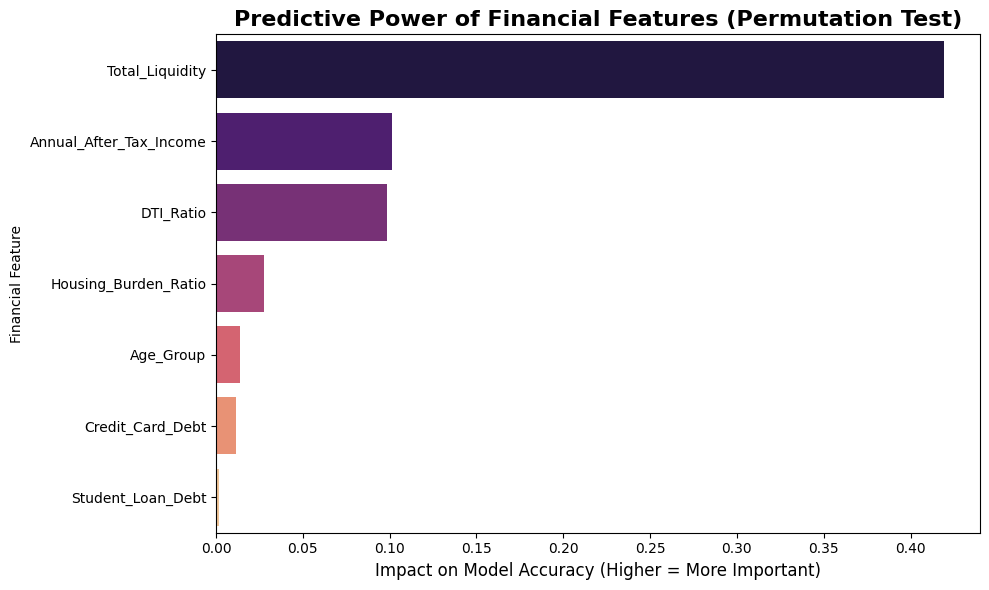

In [97]:
# FEATURE IMPORTANCE ANALYSIS
from sklearn.inspection import permutation_importance

# 1. Define the features (The "Predictors")
features = ['Age_Group', 'Annual_After_Tax_Income', 'Total_Liquidity', 
            'Housing_Burden_Ratio', 'Student_Loan_Debt', 'Credit_Card_Debt', 'DTI_Ratio']

# 2. Prepare X and y
x = df[features].fillna(0)  # fill NaNs with 0 so the model doesn't crash

y = df['Is_At_Risk_Base']

# 3. Train the Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(x, y)

# 4. Run Permutation Importance (The "Shuffle" Test)
# This evaluates how much accuracy drops when a feature is randomized
result = permutation_importance(model, x, y, n_repeats=10, random_state=42)

# 5. Create Importance DataFrame
perm_importance_df = pd.DataFrame({
    'feature': features,
    'importance': result.importances_mean
}).sort_values(by='importance', ascending=False)

# 6. Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=perm_importance_df, palette='magma')

plt.title("Predictive Power of Financial Features (Permutation Test)", fontsize=16, fontweight='bold')
plt.xlabel("Impact on Model Accuracy (Higher = More Important)", fontsize=12)
plt.ylabel("Financial Feature")
plt.tight_layout()
plt.show()

In [98]:
if "Liquidity_Months" not in df.columns:
    if "Years_of_Runway" in df.columns:
        df["Liquidity_Months"] = df["Years_of_Runway"] * 12
    else:
        raise KeyError("No Liquidity_Months or Years_of_Runway found. Run the resilience/feature engineering cell first.")

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

persona_feats = ["Liquidity_Months","Housing_Burden_Ratio","DTI_Ratio","Annual_After_Tax_Income","Total_Liquidity"]

P = df[persona_feats].replace([np.inf,-np.inf], np.nan)
P = P.fillna(P.median(numeric_only=True))

P_scaled = StandardScaler().fit_transform(P)

kmeans = KMeans(n_clusters=5, random_state=42, n_init=20)
df["Persona"] = kmeans.fit_predict(P_scaled)

persona_summary = df.groupby("Persona")[persona_feats].median()
persona_summary["risk_%"] = df.groupby("Persona")["Is_At_Risk_Base"].mean() * 100
persona_summary.sort_values("risk_%", ascending=False)

,Liquidity_Months,Housing_Burden_Ratio,DTI_Ratio,Annual_After_Tax_Income,Total_Liquidity,risk_%
Persona,,,,,,
1,1680.000000,0.300000,800.0,25.0,2100.0,100.000000
2,15600.000000,280.000000,121.0,50.0,39000.0,100.000000
0,5.133334,0.052659,0.0,70500.0,18250.0,47.474984
4,12.446243,0.000000,0.0,192125.0,140000.0,28.620261
3,217.549535,0.000000,0.0,111925.0,1080000.0,8.733624


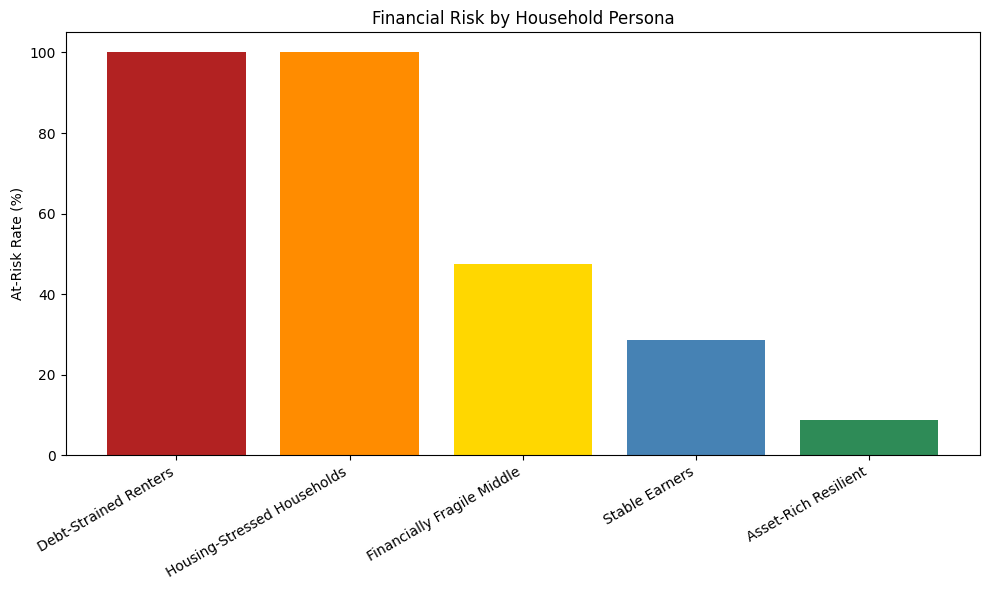

In [99]:
persona_colors = {
    0: "#B22222",   
    1: "#FF8C00",   
    2: "#FFD700",   
    3: "#4682B4",   
    4: "#2E8B57"    
}

# First assign names based on sorted order
persona_summary = persona_summary.sort_values("risk_%", ascending=False).reset_index()

persona_names = [
    "Debt-Strained Renters",
    "Housing-Stressed Households",
    "Financially Fragile Middle",
    "Stable Earners",
    "Asset-Rich Resilient"
]

persona_summary["Persona_Name"] = persona_names[:len(persona_summary)]

# Define colors from high risk to low risk
colors = ["#B22222", "#FF8C00", "#FFD700", "#4682B4", "#2E8B57"]

plt.figure(figsize=(10,6))
plt.bar(persona_summary["Persona_Name"], persona_summary["risk_%"], color=colors[:len(persona_summary)])
plt.xticks(rotation=30, ha="right")
plt.ylabel("At-Risk Rate (%)")
plt.title("Financial Risk by Household Persona")
plt.tight_layout()
plt.show()

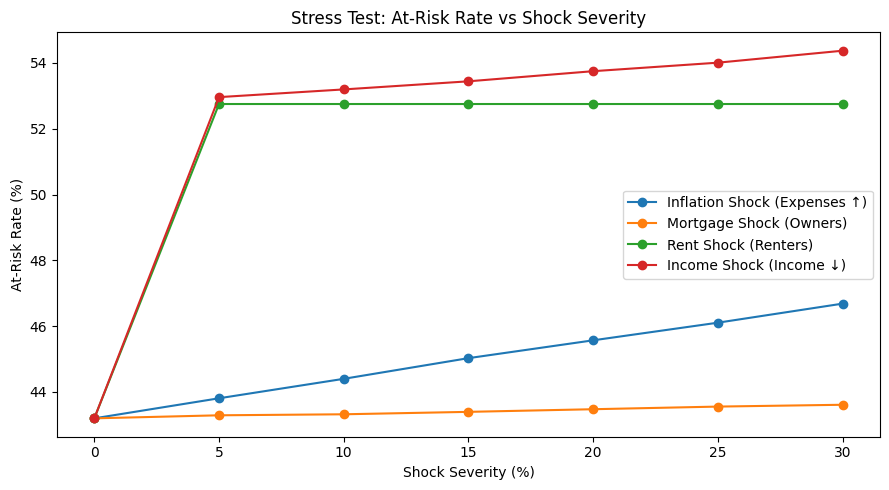

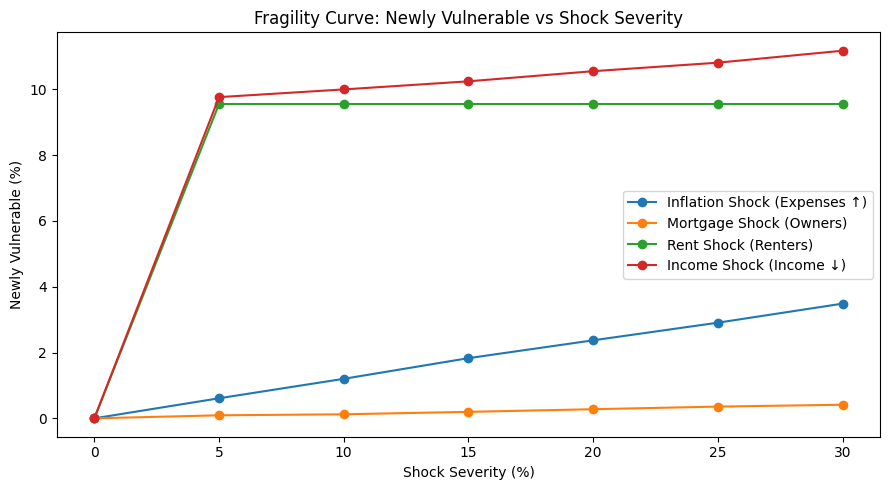

If inflation rises 30%, 46.7% of households are at risk.
3.5% become newly vulnerable under this inflation shock.

If mortgage costs rise 30%, 43.6% of households are at risk.
0.4% become newly vulnerable under this mortgage shock.

If rent rises 30%, 52.7% of households are at risk.
9.5% become newly vulnerable under this rent shock.

If income falls 30%, 54.4% of households are at risk.
11.2% become newly vulnerable under this income shock.


In [100]:
# Sensitivity Analysis: Stress Test Curves by Shock Severity
# How does vulnerability change as shock severity increases?
# Uses apply_economic_shock(...) so we can test: expenses (inflation), income, mortgage, rent.

def stress_test_curve(df, shock_type="expenses", shock_grid=np.arange(0, 0.31, 0.05)):
    df = df.copy()

    # Make sure baseline exists
    if "Is_At_Risk_Base" not in df.columns:
        raise KeyError("Is_At_Risk_Base not found. Run define_resilience(...) first.")

    rates = []
    newly_vuln = []

    for s in shock_grid:
        # Newly vulnerable under this shock severity (0/1)
        became_vulnerable = apply_economic_shock(df, shock_type=shock_type, severity=s)

        # Total at-risk after shock = baseline at-risk OR became vulnerable
        total_at_risk = ((df["Is_At_Risk_Base"] == 1) | (became_vulnerable == 1)).mean() * 100

        rates.append(total_at_risk)
        newly_vuln.append(became_vulnerable.mean() * 100)

    return shock_grid, rates, newly_vuln

#  Stress Test Curves by Shock Severity
shock_grid = np.arange(0, 0.31, 0.05)

# Inflation / expense shock
shock_grid, rates_exp, newly_exp = stress_test_curve(df, shock_type="expenses", shock_grid=shock_grid)

# Housing shocks - increasing mortgage for owners, rent for renters
shock_grid, rates_mort, newly_mort = stress_test_curve(df, shock_type="mortgage", shock_grid=shock_grid)
shock_grid, rates_rent, newly_rent = stress_test_curve(df, shock_type="rent", shock_grid=shock_grid)

# Income shock - decreasing income for everyone
shock_grid, rates_inc, newly_inc = stress_test_curve(df, shock_type="income", shock_grid=shock_grid)

# Plot all curves together for comparison
plt.figure(figsize=(9,5))
plt.plot(shock_grid*100, rates_exp,  marker="o", label="Inflation Shock (Expenses ↑)")
plt.plot(shock_grid*100, rates_mort, marker="o", label="Mortgage Shock (Owners)")
plt.plot(shock_grid*100, rates_rent, marker="o", label="Rent Shock (Renters)")
plt.plot(shock_grid*100, rates_inc,  marker="o", label="Income Shock (Income ↓)")
plt.xlabel("Shock Severity (%)")
plt.ylabel("At-Risk Rate (%)")
plt.title("Stress Test: At-Risk Rate vs Shock Severity")
plt.legend()
plt.tight_layout()
plt.show()


# Plot Newly Vulnerable ----
plt.figure(figsize=(9,5))
plt.plot(shock_grid*100, newly_exp,  marker="o", label="Inflation Shock (Expenses ↑)")
plt.plot(shock_grid*100, newly_mort, marker="o", label="Mortgage Shock (Owners)")
plt.plot(shock_grid*100, newly_rent, marker="o", label="Rent Shock (Renters)")
plt.plot(shock_grid*100, newly_inc,  marker="o", label="Income Shock (Income ↓)")
plt.xlabel("Shock Severity (%)")
plt.ylabel("Newly Vulnerable (%)")
plt.title("Fragility Curve: Newly Vulnerable vs Shock Severity")
plt.legend()
plt.tight_layout()
plt.show()


# Executive summary interpretation: "If inflation rises 30%, X% of households become at risk, X% become newly vulnerable."

shock_level = 0.30
index_30 = int(np.argmin(np.abs(shock_grid - shock_level)))

print(f"If inflation rises 30%, {rates_exp[index_30]:.1f}% of households are at risk.")
print(f"{newly_exp[index_30]:.1f}% become newly vulnerable under this inflation shock.\n")

print(f"If mortgage costs rise 30%, {rates_mort[index_30]:.1f}% of households are at risk.")
print(f"{newly_mort[index_30]:.1f}% become newly vulnerable under this mortgage shock.\n")

print(f"If rent rises 30%, {rates_rent[index_30]:.1f}% of households are at risk.")
print(f"{newly_rent[index_30]:.1f}% become newly vulnerable under this rent shock.\n")

print(f"If income falls 30%, {rates_inc[index_30]:.1f}% of households are at risk.")
print(f"{newly_inc[index_30]:.1f}% become newly vulnerable under this income shock.")

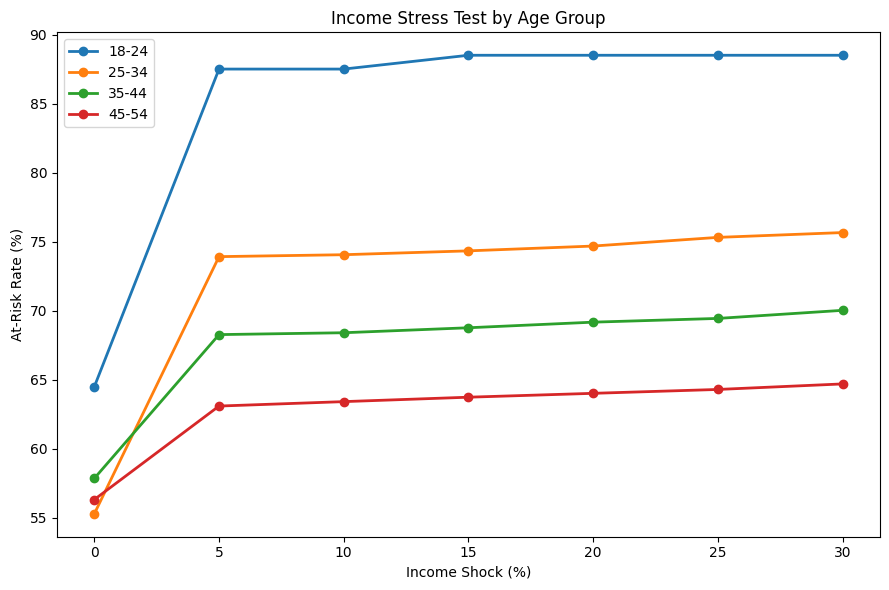

In [101]:
import matplotlib.pyplot as plt
import numpy as np

age_labels = {1:"18-24", 2:"25-34", 3:"35-44", 4:"45-54"}
shock_grid = np.arange(0, 0.31, 0.05)

plt.figure(figsize=(9,6))

for ag in sorted(age_labels.keys()):
    if ag in df["Age_Group"].unique():
        sub = df[df["Age_Group"] == ag]
        _, rates, _ = stress_test_curve(sub, shock_type="income", shock_grid=shock_grid)
        plt.plot(shock_grid*100, rates, marker="o", label=age_labels[ag], linewidth=2)

plt.xlabel("Income Shock (%)")
plt.ylabel("At-Risk Rate (%)")
plt.title("Income Stress Test by Age Group")
plt.legend()
plt.tight_layout()
plt.show()

In [102]:
age_labels = {1:"18-24", 2:"25-34", 3:"35-44", 4:"45-54"}
shock_grid = np.arange(0, 0.31, 0.05)

shock_titles = {
    "expenses": "Inflation Shock (Expenses ↑)",
    "income": "Income Shock (Income ↓)",
    "mortgage": "Mortgage Shock (Owners)",
    "rent": "Rent Shock (Renters)"
}

shock_level = 30.0  # report at 30% (or nearest point in grid)
idx_30 = int(np.argmin(np.abs(shock_grid * 100 - shock_level)))
shock_at = float(shock_grid[idx_30] * 100)

def slope_of_curve(x, y):
    """
    Sensitivity slope from a linear fit.

    Interpretation:
    The slope is how many percentage points the At-Risk rate increases
    for each 1% increase in shock severity.
    """
    return float(np.polyfit(x, y, 1)[0]) if len(x) >= 2 else np.nan

def build_shock_df(df, shock_type, shock_name):
    rows = []
    for code, label in age_labels.items():
        if code not in df["Age_Group"].unique():
            continue

        sub = df[df["Age_Group"] == code]
        _, rates, newly = stress_test_curve(sub, shock_type=shock_type, shock_grid=shock_grid)

        for s, r, n in zip(shock_grid, rates, newly):
            rows.append({
                "Shock_Type": shock_type,
                "Shock_Name": shock_name,
                "Age_Group": label,
                "Shock_%": float(s * 100),
                "At_Risk_%": float(r),
                "Newly_Vulnerable_%": float(n),
            })
    return pd.DataFrame(rows)

def summarize_shock(shock_df, shock_name):
    # Sensitivity (slope) by age group
    sens_df = (
        shock_df.sort_values("Shock_%")
        .groupby("Age_Group")
        .apply(lambda g: slope_of_curve(g["Shock_%"].values, g["At_Risk_%"].values))
        .reset_index(name="Sensitivity_Slope")
        .sort_values("Sensitivity_Slope", ascending=False)
    )

    most = sens_df.iloc[0]
    least = sens_df.iloc[-1]

    # Gap at 30% shock (nearest grid point)
    sub30 = shock_df[shock_df["Shock_%"] == shock_at].copy()
    gap_30 = float(sub30["At_Risk_%"].max() - sub30["At_Risk_%"].min())
    worst = sub30.loc[sub30["At_Risk_%"].idxmax()]
    best  = sub30.loc[sub30["At_Risk_%"].idxmin()]

    # Interpretation:
    print(f"\n--- {shock_name} ---")
    print(f"Most sensitive age group: {most['Age_Group']} "
          f"(+{most['Sensitivity_Slope']:.3f} risk-pts per 1% shock)")
    print(f"At {shock_at:.0f}% shock, age risk gap = {gap_30:.1f} pts "
          f"(highest: {worst['Age_Group']}, lowest: {best['Age_Group']})")

    return {
        "Shock": shock_name,
        "Most_Sensitive_Age": most["Age_Group"],
        "Most_Sensitive_Slope": float(most["Sensitivity_Slope"]),
        "Least_Sensitive_Age": least["Age_Group"],
        "Least_Sensitive_Slope": float(least["Sensitivity_Slope"]),
        f"Gap_At_{int(shock_at)}%_Shock_(pts)": gap_30,
        f"Highest_At_{int(shock_at)}%": f"{worst['Age_Group']} ({worst['At_Risk_%']:.1f}%)",
        f"Lowest_At_{int(shock_at)}%":  f"{best['Age_Group']} ({best['At_Risk_%']:.1f}%)",
    }

# Run all shocks 
shock_dfs = []
summary_rows = []

for shock_type, shock_name in shock_titles.items():
    shock_df = build_shock_df(df, shock_type, shock_name)
    shock_dfs.append(shock_df)
    summary_rows.append(summarize_shock(shock_df, shock_name))

all_shocks_df = pd.concat(shock_dfs, ignore_index=True)
summary_df = pd.DataFrame(summary_rows)

# Optional rounding for display
for c in ["Most_Sensitive_Slope", "Least_Sensitive_Slope", f"Gap_At_{int(shock_at)}%_Shock_(pts)"]:
    if c in summary_df.columns:
        summary_df[c] = summary_df[c].round(2)

print("\n       -----SUMMARY TABLE (all shocks)-----      ")
summary_df


--- Inflation Shock (Expenses ↑) ---
Most sensitive age group: 45-54 (+0.145 risk-pts per 1% shock)
At 30% shock, age risk gap = 8.8 pts (highest: 18-24, lowest: 25-34)

--- Income Shock (Income ↓) ---
Most sensitive age group: 18-24 (+0.536 risk-pts per 1% shock)
At 30% shock, age risk gap = 23.8 pts (highest: 18-24, lowest: 45-54)

--- Mortgage Shock (Owners) ---
Most sensitive age group: 35-44 (+0.035 risk-pts per 1% shock)
At 30% shock, age risk gap = 9.1 pts (highest: 18-24, lowest: 25-34)

--- Rent Shock (Renters) ---
Most sensitive age group: 18-24 (+0.493 risk-pts per 1% shock)
At 30% shock, age risk gap = 24.6 pts (highest: 18-24, lowest: 45-54)

       -----SUMMARY TABLE (all shocks)-----      


,Shock,Most_Sensitive_Age,Most_Sensitive_Slope,Least_Sensitive_Age,Least_Sensitive_Slope,Gap_At_30%_Shock_(pts),Highest_At_30%,Lowest_At_30%
0,Inflation Shock (Expenses ↑),45-54,0.14,18-24,0.12,8.79,18-24 (68.0%),25-34 (59.2%)
1,Income Shock (Income ↓),18-24,0.54,45-54,0.20,23.80,18-24 (88.5%),45-54 (64.7%)
2,Mortgage Shock (Owners),35-44,0.04,25-34,0.02,9.07,18-24 (65.0%),25-34 (55.9%)
3,Rent Shock (Renters),18-24,0.49,45-54,0.14,24.64,18-24 (87.5%),45-54 (62.9%)
